In [6]:
#[실습 03-01]


!pip install koreanize_matplotlib

import koreanize_matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                                   # 시각화 라이브러리
import numpy as np                                      # 다차원 배열, 수치 계산 수행
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
#[실습 03-02]

df = pd.read_csv("베이스볼.csv", encoding='cp949')
df

,max_speed,fourball,strikeout,era
0,158,5,7,3.37
1,149,5,4,3.01
2,153,7,0,3.83
3,136,5,6,3.44
4,140,7,4,4.16
...,...,...,...,...
95,144,5,7,2.71
96,151,5,3,3.64
97,164,4,3,3.73
98,148,7,2,3.98


In [3]:
#[실습 03-03]
df.describe()

,max_speed,fourball,strikeout,era
count,100.00000,100.000000,100.000000,100.000000
mean,150.30000,3.700000,4.840000,3.078000
std,8.88251,2.388948,3.073905,0.707328
min,135.00000,0.000000,0.000000,1.670000
25%,144.00000,2.000000,2.000000,2.515000
50%,152.00000,4.000000,5.000000,3.055000
75%,157.00000,6.000000,8.000000,3.577500
max,165.00000,7.000000,10.000000,5.010000


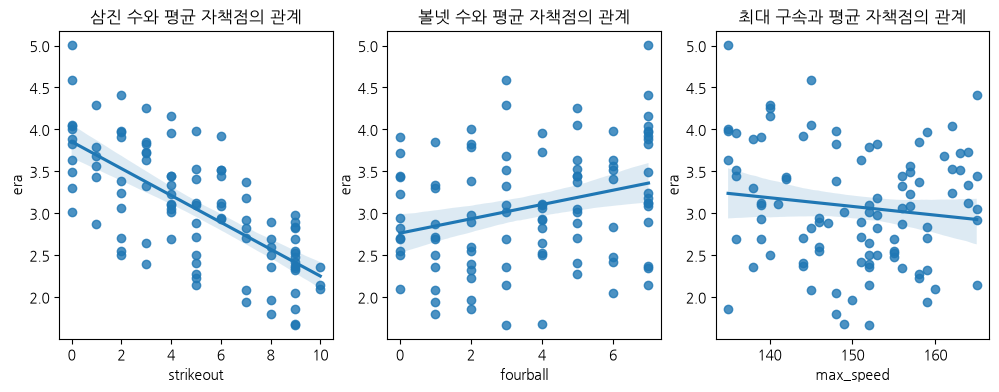

In [8]:
#[실습 03-04]

plt.figure(figsize=(12,4))

#삼진 수와 평균 자책점의 관계
plt.subplot(1,3,1)
sns.regplot(x='strikeout',y='era',data=df)
plt.title("삼진 수와 평균 자책점의 관계")

#볼넷 수와 평균 자책점의 관계
plt.subplot(1,3,2)
sns.regplot(x='fourball',y='era',data=df)
plt.title("볼넷 수와 평균 자책점의 관계")

#최대 구속과 평균 자책점의 관계
plt.subplot(1,3,3)
sns.regplot(x='max_speed',y='era',data=df)
plt.title("최대 구속과 평균 자책점의 관계")

plt.show()

머신러닝 모델을 설정하는 과정
1. 타깃과 입력 지정하기 (입력 변수/타깃 변수)
2. 예측 함수 설정하기

타깃 : 모델이 예측하려는 대상이 되는 변수
입력 : 타깃을 예측하는 데 사용하는 특성 변수

In [11]:
#[실습 03-05]
#삼진 수만 사용해서 평균 자책점 예측

y=df['era']             # 타깃 지정
X=df[['strikeout']]     # 입력 지정
# LinearRegression 모델 클래스는 입력 변수를 항상 2차원 배열 [[]] 형태로 요구


In [12]:
#[실습 03-06]
#임의의 파라미터로 예측하기

w = -0.5;
b = 5

df["pred_era"] = w*X + b
df["error"] = df["era"] - df["pred_era"]

df

,max_speed,fourball,strikeout,era,pred_era,error
0,158,5,7,3.37,1.5,1.87
1,149,5,4,3.01,3.0,0.01
2,153,7,0,3.83,5.0,-1.17
3,136,5,6,3.44,2.0,1.44
4,140,7,4,4.16,3.0,1.16
...,...,...,...,...,...,...
95,144,5,7,2.71,1.5,1.21
96,151,5,3,3.64,3.5,0.14
97,164,4,3,3.73,3.5,0.23
98,148,7,2,3.98,4.0,-0.02


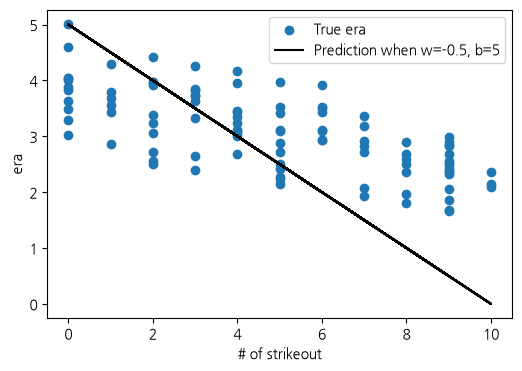

In [13]:
#[실습 03-07]
#예측 결과 시각화하기_예측한 평균 자책점과 실제 평균 자책점이 얼마나 유사한가?

plt.figure(figsize=(6,4))
plt.scatter(df["strikeout"],df["era"],label = "True era")
plt.plot(df["strikeout"],df["pred_era"],"k-",label = f'Prediction when w={w}, b={b}')
plt.xlabel('# of strikeout');
plt.ylabel("era")
plt.legend()
plt.show()

임의로 설정한 파라미터로 계산한 예측 직선이
실제 데이터랑 크게 차이를 보인다
-> 현재 파라미터로는 모델이 실제 데이터를 정확하게 예측 X

In [ ]:
#[실습 03-08]
#예측 오차 평가하기

MSE = np.mean(df['error']**2) # error = 실제 ERA - 예측 ERA
print('평균제곱오차 =',np.round(MSE,3)) # 소수점 셋째 자리까지 반올림

평균제곱오차 = 1.582


In [ ]:
#[MSE로 구하는 함수 정의]

def mse(true,pred):
    q = np.mean((true-pred)**2)
    return q

z = mse(y,df['pred_era'])
print(f"mse 함수로 계산한 평균제곱오차 = {z: .3f}")

mse 함수로 계산한 평균제곱오차 =  1.582


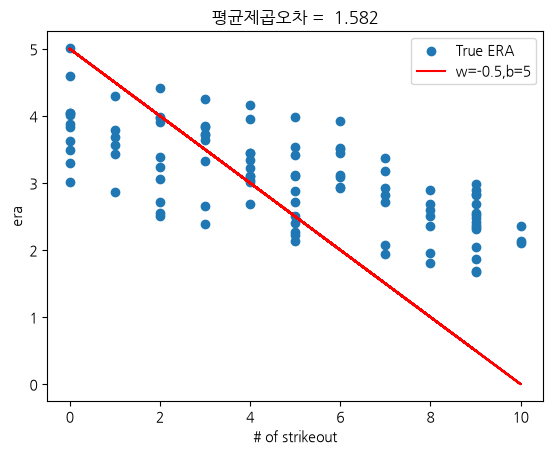

In [16]:
#[실습 03-09]

MSE = np.mean(df['error']**2)

plt.scatter(df["strikeout"],df["era"],label = "True ERA")
plt.plot(df["strikeout"],df["pred_era"],"r",label = f'w={w},b={b}')
plt.xlabel('# of strikeout');
plt.ylabel("era")
plt.legend()
plt.title(f"평균제곱오차 = {MSE: .3f}")
plt.show()

In [17]:
#[실습 03-10]

#모델 설정
model = LinearRegression()

#모델 학습
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.16]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['strikeout']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.854
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [18]:
#[실습 03-11]

print("가중치(weights)=",model.coef_)
print("편향(bias)=",model.intercept_)

가중치(weights)= [-0.1603438]
편향(bias)= 3.8540639698965196


In [19]:
#[실습 03-12]
# 예측 결과 확인

y_pred = model.predict(X)
y_pred[:10]

array([2.7316574 , 3.21268879, 3.85406397, 2.8920012 , 3.21268879,
       3.85406397, 3.69372017, 3.85406397, 3.85406397, 3.05234499])

In [20]:
#[실습 03-13]
# 손실 계산
MSE = mse(y,y_pred)
print(f"평균제곱오차 = {MSE: .4f}")

평균제곱오차 =  0.2548


In [21]:
# 최종 손실 계산하기 - 라이브러리 함수
from sklearn.metrics import mean_squared_error
mean_squared_error(y,y_pred)

0.25480713435388685

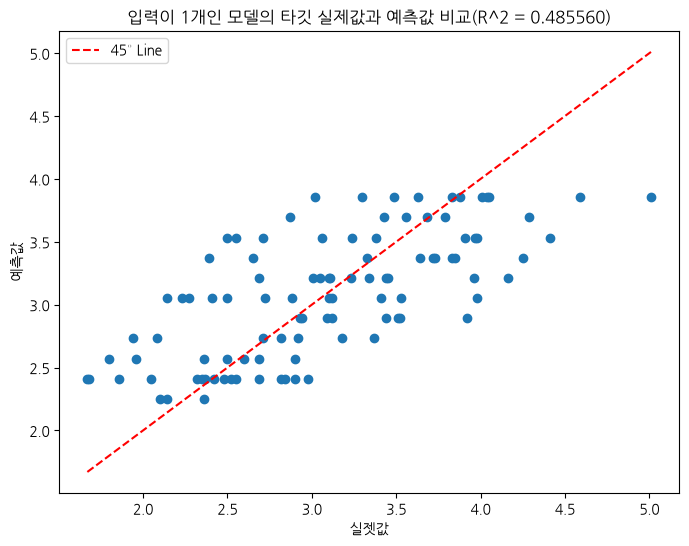

In [ ]:
#[실습 03-14]
# 예측 성능 시각화

#학습된 모델로 예측값 계산
y_pred = model.predict(X)

from sklearn.metrics import mean_squared_error, r2_score
#R^2 계산
acc = r2_score(y,y_pred)

#실제값과 예측값을 비교하는 45도 기준선이 있는 산점도 시각화
plt.figure(figsize=(8,6))
plt.scatter(y,y_pred)
plt.plot(
    [y.min(), y.max()], [y.min(), y.max()],
    color = 'red', linestyle = '--', label = '45° Line'
)

plt.title(f'입력이 1개인 모델의 타깃 실제값과 예측값 비교(R^2 = {acc:.3f})')
plt.xlabel('실젯값')
plt.ylabel('예측값')
plt.legend()
plt.show()

In [24]:
#[실습 03-15]
# 입력 변수 1개->3개로 확징하여 모델 개선

y = df['era']
X = df[['strikeout','fourball','max_speed']]

from sklearn.linear_model import LinearRegression
model2 = LinearRegression()
model2.fit(X,y)

print("가중치(weights) =",model2.coef_)
print("편향(bias) =",model2.intercept_)
print()

y_pred = model2.predict(X)
MSE = mean_squared_error(y,y_pred)
print("평균제곱오차 =",MSE)

가중치(weights) = [-0.15720595  0.07475011 -0.00907497]
편향(bias) = 4.926268916009342

평균제곱오차 = 0.216096211572705


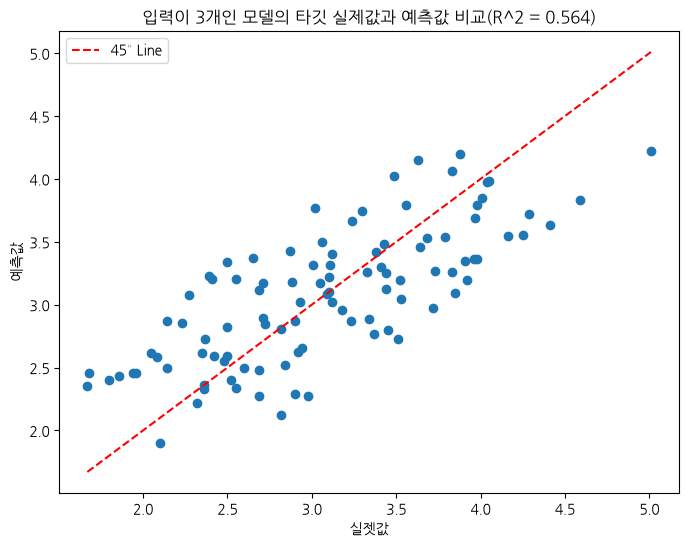

In [26]:
# 예측 성능 시각화

#학습된 모델로 예측값 계산
y_pred = model2.predict(X)

from sklearn.metrics import mean_squared_error, r2_score
#R^2 계산
acc = r2_score(y,y_pred)

#실제값과 예측값을 비교하는 45도 기준선이 있는 산점도 시각화
plt.figure(figsize=(8,6))
plt.scatter(y,y_pred)
plt.plot(
    [y.min(), y.max()], [y.min(), y.max()],
    color = 'red', linestyle = '--', label = '45° Line'
)

plt.title(f'입력이 3개인 모델의 타깃 실제값과 예측값 비교(R^2 = {acc:.3f})')
plt.xlabel('실젯값')
plt.ylabel('예측값')
plt.legend()
plt.show()

In [27]:
#[실습 03-16]

# 에를 들어, 어떤 구단이 9이닝 당 삼진 10, 볼넷 0, 최대구속 160km/h인 새 투수 영입 희망
# 이떄, 이 투수가 다음 시즌에 기록할 평균 자책점은?

import warnings
warnings.filterwarnings('ignore')

X_new = [[10,0,160]]

print(f"이 투수의 평균 자책점은 {model2.predict(X_new)}로 예측됩니다.")

이 투수의 평균 자책점은 [1.90221471]로 예측됩니다.


Fangraphs.csv에는 2021년부터 2025년까지의 MLB에서 활약한 투수 205명의 기록이 저장되어 있다.
모델의 입력 변수는  ["HR/9",            "BB/9",  "K/9"]     이며, 각각
                [9이닝당 허용 홈런 수 / 볼넷 수 / 삼진 수]    를 의미한다

가중치(weights)= [ 1.36519353  0.36072037 -0.22259684]
편향(bias)= 3.2599998174177043


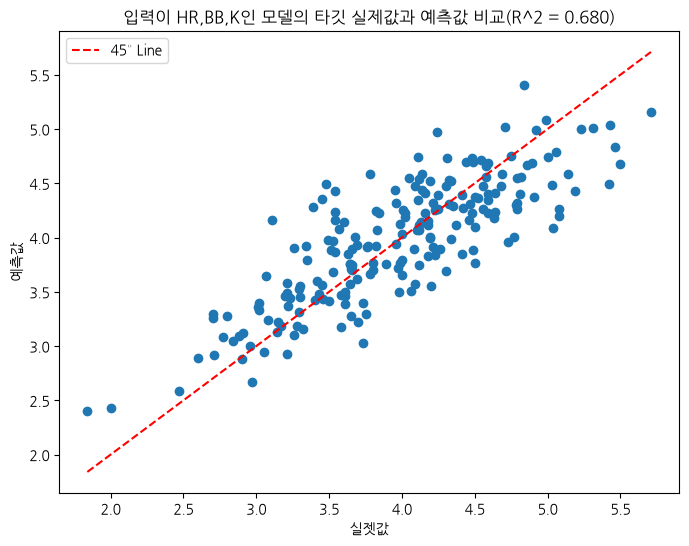

이 투수의 평균 자책점은 [3.87292954]로 예측됩니다.


In [ ]:
#되새김_3장_Q1
#평균 자책점(ERA)을 타깃으로 설정해 선형회귀모델을 학습
#학습이 끝나면 모델의 파라미터와 MSE를 출력하고, 실제값과 예측값을 비교하는 그래프로 모델의 예측 성능을 시각화
#또한 학습된 모델을 사용해 HR/9 = 1, BB/9 = 1, K/9 = 5인 투수의 ERA를 예측

!pip install koreanize_matplotlib

import koreanize_matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                                   # 시각화 라이브러리
import numpy as np                                      # 다차원 배열, 수치 계산 수행
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("Fangraphs.csv", encoding='cp949')
df

y = df['ERA']
X = df[['HR/9','BB/9','K/9']]

model3 = LinearRegression()
model3.fit(X,y)

print("가중치(weights)=",model3.coef_)
print("편향(bias)=",model3.intercept_)

#학습된 모델로 예측값 계산
y_pred = model3.predict(X)

from sklearn.metrics import mean_squared_error, r2_score
#R^2 계산
acc = r2_score(y,y_pred)

#실제값과 예측값을 비교하는 45도 기준선이 있는 산점도 시각화
plt.figure(figsize=(8,6))
plt.scatter(y,y_pred)
plt.plot(
    [y.min(), y.max()], [y.min(), y.max()],
    color = 'red', linestyle = '--', label = '45° Line'
)

plt.title(f'입력이 HR,BB,K인 모델의 타깃 실제값과 예측값 비교(R^2 = {acc:.3f})')
plt.xlabel('실젯값')
plt.ylabel('예측값')
plt.legend()
plt.show()

import warnings
warnings.filterwarnings('ignore')

X_new = [[1,1,5]]

print(f"이 투수의 평균 자책점은 {model3.predict(X_new)}로 예측됩니다.")


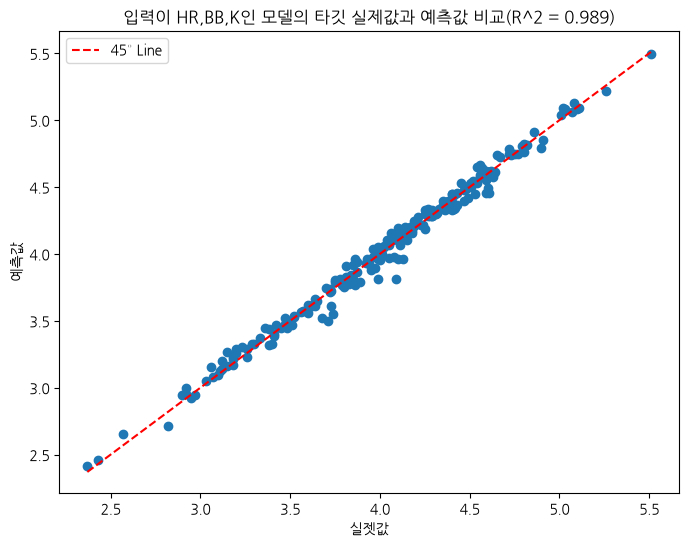

이 투수의 FIP는 [3.91499482]로 예측됩니다.


In [ ]:
#되새김_3장_Q2
#FIP는 투수의 수비 무관 평균 자책점 (투수의 종합적인 능력 평가 지표), 홈런/볼넷/삼진 기록만을 이용해 계산
# 1. FIP를 타깃으로 설정해 선형회귀모델 학습, 예측 성능 시각화
# 2. 학습된 모델로 HR/9=1, BB/9=1, K/9=5인 투수의 FIP를 예측
# 3. 선형회귀모델이 ERA보다 FIP를 더 정확하계 예측하는 이유는 무엇인가?

!pip install koreanize_matplotlib

import koreanize_matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns                                   # 시각화 라이브러리
import numpy as np                                      # 다차원 배열, 수치 계산 수행
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("Fangraphs.csv", encoding='cp949')
df

y = df['FIP']
X = df[['HR/9','BB/9','K/9']]

model4 = LinearRegression()
model4.fit(X,y)

#학습된 모델로 예측값 계산
y_pred = model4.predict(X)

from sklearn.metrics import mean_squared_error, r2_score
#R^2 계산
acc = r2_score(y,y_pred)

#실제값과 예측값을 비교하는 45도 기준선이 있는 산점도 시각화
plt.figure(figsize=(8,6))
plt.scatter(y,y_pred)
plt.plot(
    [y.min(), y.max()], [y.min(), y.max()],
    color = 'red', linestyle = '--', label = '45° Line'
)

plt.title(f'입력이 HR,BB,K인 모델의 타깃 실제값과 예측값 비교(R^2 = {acc:.3f})')
plt.xlabel('실젯값')
plt.ylabel('예측값')
plt.legend()
plt.show()

import warnings
warnings.filterwarnings('ignore')

X_new = [[1,1,5]]

print(f"이 투수의 FIP는 {model4.predict(X_new)}로 예측됩니다.")

